# Wyniki eksperymentów — przegląd

Notatnik **wyświetla** wyniki obu etapów pracy. Nie liczy niczego: każda liczba pochodzi
z plików `results/*.csv`, wyprodukowanych wcześniej przez skrypty `experiments/e1_toy.py`
i `experiments/e2_uci.py`. Cała logika tabel siedzi w `src/tables.py` (pokryta testami,
`tests/test_tables.py`), zgodnie z zasadą z `CLAUDE.md`, że kod mieszka w `src/`
i `experiments/`. Dzięki temu w notatniku nie da się „dopisać" liczby.

**Dwa etapy są rozdzielone całkowicie** — osobne sekcje, osobne tabele, osobne podpisy:

| | Część I — problem syntetyczny (E1) | Część II — dane rzeczywiste (E2) |
|---|---|---|
| dane | `y = sin(x) + N(0, 0.1²)`, wygenerowane | UCI: yacht, energy, concrete |
| powtórzenia | 20 ziaren (seedów) | 20 splitów Hernándeza-Lobato i Adamsa |
| podział wyników | 3 regiony (wnętrze / ekstrapolacja / całość) | 1 wiersz na (metoda, zbiór) |
| rysunki | **tak** — problem jest 1D, pasmo da się narysować | **nie** — z założenia, patrz Część II |
| prawdziwy poziom szumu | **znany** (0.1, z konstrukcji) | **nieznany** — nie istnieje |

**Jak odświeżyć:** `Kernel → Restart & Run All`. Notatnik czyta pliki wynikowe z dysku,
więc po ponownym przeliczeniu eksperymentów wystarczy go uruchomić od nowa.
Do wklejenia do pracy służą komórki „Eksport do LaTeX" na końcu każdej części.

In [1]:
import sys
from pathlib import Path

# the notebook lives in notebooks/, the package in the repository root
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

import pandas as pd
from IPython.display import Image, display

from src import tables as T

e1 = T.reported_rows(T.E1_CSV, ["region"])    # E1: drops --quick and --set rows
e2 = T.reported_rows(T.E2_CSV, ["dataset"])   # E2: same, latest run per dataset

print("E1:", len(e1), "wierszy |", T.E1_CSV.name)
print("E2:", len(e2), "wierszy |", T.E2_CSV.name)

E1: 360 wierszy | e1_toy_metrics.csv
E2: 360 wierszy | e2_uci_metrics.csv


C:\Users\michal\Desktop\ml_TESTYYY\.venv\Lib\site-packages\torch\jit\_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


## Jak czytać tabele

**Kolumny.** Cztery metryki obowiązkowe plus trzy diagnostyczne:

| kolumna | co mierzy | kierunek |
|---|---|---|
| **RMSE** | błąd średniej predykcyjnej — nie widzi niepewności w ogóle | mniej = lepiej |
| **LL** | średnia log-wiarygodność obserwacji testowych | **więcej = lepiej** (wartości zwykle ujemne) |
| **PICP@95** | jaka część obserwacji wpadła w przedział 95% | im bliżej **0.95**, tym lepiej |
| **MPIW@95** | średnia szerokość tego przedziału | sama w sobie **nie jest** oceną |
| `sigma_fitted` | odchylenie szumu obserwacyjnego, które metoda sobie dopasowała | diagnostyka |
| `cal_err` | średnie \|odchylenie pokrycia od nominału\| po wielu poziomach | mniej = lepiej |
| `cal_bias` | to samo, **ze znakiem** | **+ = za szerokie** (niedopewność), **− = za wąskie** (nadpewność) |

**MPIW@95 nigdy nie jest raportowane bez PICP@95** (`CLAUDE.md`): wąski przedział może
brać się z dobrej kalibracji albo z nadmiernej pewności siebie, a sama szerokość tych
dwóch przypadków nie rozróżnia. Dlatego obie kolumny zawsze stoją obok siebie.

**Po co `cal_err` i `cal_bias`, skoro jest PICP.** PICP@95 to jeden punkt krzywej
kalibracji. Para `cal_err`/`cal_bias` streszcza całą krzywą i rozdziela dwie porażki,
których jeden poziom nie odróżnia: przedział równomiernie za wąski leży pod przekątną
wszędzie, a przedział o dobrej szerokości wokół przesuniętej średniej jest płaski i niski.

**Konwencje (ustalone wcześniej, nie zmieniane tutaj).**

- Rozrzut po `±` to **odchylenie standardowe** (DEC-006 dla E1, DEC-015 dla E2), a nie błąd
  standardowy. Literatura (Hernández-Lobato i Adams, Gal i Ghahramani) podaje **błędy
  standardowe**; przy `n = 20` różnią się dokładnie o `√20 ≈ 4.472`, więc
  `SE = std / 4.472`. Zestawiając naszą tabelę z opublikowaną **trzeba to powiedzieć**,
  inaczej nasz rozrzut wygląda na 4.5× większy na tych samych danych.
- Metryki są w **oryginalnych jednostkach zmiennej celu** (DEC-003) — modele uczą się na
  danych standaryzowanych, ale predykcje są odstandaryzowane przed liczeniem metryk.
- Przedział 95% liczony z `z = 1.959964` (DEC-008), czyli dokładnym kwantylem, a nie `2σ`.
- Każda metoda oceniana jako **jeden dopasowany momentami rozkład Gaussa**
  `N(średnia, wariancja_aleatoryczna + wariancja_epistemiczna)` (DEC-009), łącznie
  z metodami próbkującymi. To jedna konwencja dla wszystkich sześciu — co czyni kolumny
  porównywalnymi między sobą, ale **nie** z tabelami Gala, który raportuje mieszankę
  log-sum-exp.

**Skróty metod:** `map` — deterministyczny punkt odniesienia (MAP), `mcd` — MC dropout,
`ensemble` — deep ensemble, `bbb` — Bayes by Backprop, `laplace` — aproksymacja Laplace'a,
`gp` — proces gaussowski (jedyna metoda z dokładną, nie przybliżoną, posterior).

---
# Część I — problem syntetyczny (E1)

**Zadanie.** `y = sin(x) + N(0, σ²)`, punkty treningowe losowane jednostajnie z `[0, 6]`,
siatka testowa rozciągnięta na `[-2, 8]` — czyli **wychodzi poza dane treningowe po obu
stronach**. To jest cały sens tego etapu: sprawdzić, co metody robią z niepewnością tam,
gdzie nie widziały danych.

**Dlaczego trzy regiony.** Pojedyncza liczba policzona po całym `[-2, 8]` uśrednia
interpolację z ekstrapolacją i zakrywa dokładnie to zachowanie, o które w tym rozdziale
chodzi. Dlatego każda metryka raportowana jest osobno w trzech regionach, a `overall`
to suma dwóch pozostałych, podana obok nich, a nie zamiast nich.

**Tu — i tylko tu — prawdziwy poziom szumu jest znany**, bo dane są generowane
(`σ = 0.1`). Kolumna `sigma_fitted` czyta się więc względem prawdy. W Części II tak
**nie** jest.

In [2]:
config = T.e1_configuration(e1)
print("konfiguracja E1 (odczytana z wierszy wynikowych, nie wpisana ręcznie):")
for key, value in config.items():
    print("  {:14s} {}".format(key, value))
print()
print("liczba powtórzeń na region:",
      {r: T.repetitions(e1, "region", r) for r in T.E1_REGION_ORDER})

konfiguracja E1 (odczytana z wierszy wynikowych, nie wpisana ręcznie):
  n_train        250
  grid_points    500
  noise_sigma    0.1
  epochs         4000
  seeds          20
  torch_threads  1
  run_id         20260905T005453Z

liczba powtórzeń na region: {'in_range': 20, 'extrapolation': 20, 'overall': 20}


## I.1 Tabele metryk — komplet, po jednej na region

Wszystkie sześć metod i wszystkie siedem kolumn, oddzielnie dla każdego regionu.
Rozrzut = odchylenie standardowe po 20 ziarnach.

In [3]:
e1_tables = T.stage_tables(e1, "region", T.E1_REGION_ORDER)
n_e1 = T.repetitions(e1, "region", "in_range")

display(T.style(
    e1_tables["in_range"],
    "E1 — {} · średnia ± odchylenie standardowe po {} ziarnach · oryginalne jednostki y"
    .format(T.E1_REGION_TITLES["in_range"], n_e1)))

,RMSE,LL,PICP@95,MPIW@95,sigma_fitted,cal_err,cal_bias
metoda,,,,,,,
map,0.102 ± 0.006,0.857 ± 0.059,0.943 ± 0.019,0.396 ± 0.016,0.1011 ± 0.0042,0.0238 ± 0.0100,-0.0012 ± 0.0240
mcd,0.154 ± 0.008,0.310 ± 0.045,0.999 ± 0.003,0.949 ± 0.052,0.2018 ± 0.0120,0.1352 ± 0.0169,0.1352 ± 0.0169
ensemble,0.100 ± 0.005,0.875 ± 0.045,0.950 ± 0.016,0.400 ± 0.017,0.1007 ± 0.0043,0.0240 ± 0.0113,0.0053 ± 0.0242
bbb,0.102 ± 0.004,0.857 ± 0.041,0.950 ± 0.015,0.406 ± 0.017,0.1027 ± 0.0044,0.0220 ± 0.0110,0.0041 ± 0.0221
laplace,0.102 ± 0.006,0.858 ± 0.057,0.947 ± 0.018,0.402 ± 0.016,0.1011 ± 0.0042,0.0236 ± 0.0102,0.0035 ± 0.0238
gp,0.100 ± 0.005,0.879 ± 0.045,0.947 ± 0.019,0.394 ± 0.017,0.0993 ± 0.0043,0.0229 ± 0.0112,0.0028 ± 0.0234


**Region wewnętrzny — co widać.** Tam gdzie są dane treningowe, wszystkie metody poza
`mcd` wyglądają praktycznie tak samo: RMSE ≈ 0.10 (czyli na poziomie samego szumu, 0.1 —
lepiej się nie da), PICP blisko nominalnych 0.95, `sigma_fitted` ≈ 0.1. **To jest wynik
pozytywny i trzeba go tak czytać**: w interpolacji pięć z sześciu metod jest dobrze
skalibrowanych i nie ma między nimi istotnej różnicy.

`mcd` odstaje: przedział 2.4× szerszy od pozostałych, PICP 0.999 zamiast 0.95
i `sigma_fitted` dwa razy za duże. To finding N-001 — wrócimy do niego w tabeli I.3.

In [4]:
display(T.style(
    e1_tables["extrapolation"],
    "E1 — {} · średnia ± odchylenie standardowe po {} ziarnach · oryginalne jednostki y"
    .format(T.E1_REGION_TITLES["extrapolation"], n_e1)))

,RMSE,LL,PICP@95,MPIW@95,sigma_fitted,cal_err,cal_bias
metoda,,,,,,,
map,0.359 ± 0.070,-5.227 ± 2.710,0.585 ± 0.066,0.396 ± 0.016,0.1011 ± 0.0042,0.2546 ± 0.0385,-0.2546 ± 0.0385
mcd,0.806 ± 0.077,-4.186 ± 0.896,0.156 ± 0.054,1.048 ± 0.054,0.2018 ± 0.0120,0.5217 ± 0.0204,-0.5217 ± 0.0204
ensemble,0.347 ± 0.047,-3.143 ± 1.240,0.622 ± 0.055,0.432 ± 0.033,0.1007 ± 0.0043,0.2302 ± 0.0305,-0.2302 ± 0.0305
bbb,0.210 ± 0.048,-0.780 ± 1.077,0.689 ± 0.136,0.410 ± 0.018,0.1027 ± 0.0044,0.2106 ± 0.0866,-0.2106 ± 0.0866
laplace,0.359 ± 0.070,-0.010 ± 0.165,0.923 ± 0.057,0.924 ± 0.113,0.1011 ± 0.0042,0.0782 ± 0.0456,-0.0636 ± 0.0631
gp,0.267 ± 0.123,0.028 ± 0.301,0.962 ± 0.064,1.144 ± 0.065,0.0993 ± 0.0043,0.1143 ± 0.0713,0.0218 ± 0.1333


**Region ekstrapolacji — tu metody się rozjeżdżają, i to jest główny wynik E1.**
Poza zakresem treningowym RMSE rośnie wszystkim (bo `sin` trzeba zgadnąć), ale liczy się,
co się dzieje z **niepewnością**:

- `gp` i `laplace` poszerzają pasmo i utrzymują pokrycie — LL zostaje blisko zera.
- `map` nie ma członu epistemicznego w ogóle (z definicji: `var_epistemic ≡ 0`), więc jego
  pasmo się nie zmienia, pokrycie leci do ~0.59, a LL się załamuje.
- `ensemble` i `bbb` poszerzają pasmo tylko odrobinę — za mało, żeby nadążyć za błędem.
- **`mcd` jest tu najciekawszy i najbardziej pouczający.** Ma najszersze pasmo ze wszystkich
  (`MPIW` 1.048), a mimo to pokrywa zaledwie **0.156** obserwacji — najgorzej z całej szóstki,
  przy `cal_bias` −0.522. Powód: jego pasmo jest szerokie *równomiernie*, bo bierze się
  z globalnego członu szumu, a nie z wiedzy o tym, gdzie kończą się dane; średnia
  predykcyjna jest tymczasem poza zakresem mocno błędna (RMSE 0.806, najgorsze).

**To jest dokładnie powód, dla którego `MPIW` nigdy nie jest raportowane bez `PICP`.**
Gdyby patrzeć na samą szerokość, `mcd` wyglądałby na najostrożniejszą metodę w tabeli;
patrząc na pokrycie, jest najbardziej nadpewny. Szerokie pasmo w złym miejscu nie jest
ostrożnością.

Innymi słowy: **poza danymi treningowymi kalibrację utrzymują tylko `gp` i `laplace`**.
Reszta jest nadmiernie pewna siebie i mówi to głosem ujemnego `cal_bias`.

In [5]:
display(T.style(
    e1_tables["overall"],
    "E1 — {} · średnia ± odchylenie standardowe po {} ziarnach · oryginalne jednostki y"
    .format(T.E1_REGION_TITLES["overall"], n_e1)))

,RMSE,LL,PICP@95,MPIW@95,sigma_fitted,cal_err,cal_bias
metoda,,,,,,,
map,0.241 ± 0.042,-1.576 ± 1.089,0.800 ± 0.032,0.396 ± 0.016,0.1011 ± 0.0042,0.1026 ± 0.0227,-0.1026 ± 0.0227
mcd,0.523 ± 0.048,-1.489 ± 0.358,0.662 ± 0.023,0.989 ± 0.052,0.2018 ± 0.0120,0.1289 ± 0.0124,-0.1276 ± 0.0131
ensemble,0.233 ± 0.028,-0.732 ± 0.500,0.819 ± 0.027,0.413 ± 0.021,0.1007 ± 0.0043,0.0891 ± 0.0208,-0.0889 ± 0.0211
bbb,0.155 ± 0.027,0.202 ± 0.433,0.846 ± 0.054,0.408 ± 0.017,0.1027 ± 0.0044,0.0820 ± 0.0367,-0.0818 ± 0.0368
laplace,0.241 ± 0.042,0.511 ± 0.076,0.938 ± 0.027,0.611 ± 0.048,0.1011 ± 0.0042,0.0318 ± 0.0213,-0.0234 ± 0.0295
gp,0.188 ± 0.071,0.539 ± 0.132,0.953 ± 0.032,0.694 ± 0.031,0.0993 ± 0.0043,0.0478 ± 0.0329,0.0104 ± 0.0570


**Region `overall` — podany dla kompletności, ale to najmniej informatywna z trzech
tabel.** Miesza interpolację z ekstrapolacją w proporcji wynikającej z tego, jak
przypadkiem podzielono siatkę (300 punktów w zakresie, 200 poza). Do wniosków w pracy
lepiej cytować dwa poprzednie regiony osobno.

## I.2 Kontrola strukturalna — czy pasmo w ogóle się poszerza poza danymi

Iloraz `MPIW@95` w ekstrapolacji do `MPIW@95` w zakresie treningowym. To jest test
sprawdzający całą pipeline'ę, nie tylko metody: jeśli to uporządkowanie by nie wyszło,
należałoby podejrzewać błąd w kodzie, zanim uwierzy się w jakąkolwiek liczbę wyżej.

In [6]:
display(T.style(
    T.e1_band_expansion(e1),
    "E1 — poszerzenie pasma poza zakresem treningowym (iloraz średnich MPIW@95)"))

,MPIW@95 w zakresie,MPIW@95 ekstrapolacja,iloraz
metoda,,,
gp,0.394000,1.144000,2.900000
laplace,0.402000,0.924000,2.300000
mcd,0.949000,1.048000,1.100000
ensemble,0.400000,0.432000,1.080000
bbb,0.406000,0.410000,1.010000
map,0.396000,0.396000,1.000000


**Oczekiwanie z teorii i literatury było takie:** `gp` i `laplace` mocno, `ensemble`
trochę, `bbb` ledwo, `map` wcale (dokładnie 1.00, bo nie ma czego poszerzać).
Uporządkowanie się zgadza — i `map` daje równo 1.00, co jest sanity-checkiem samym w sobie.

`mcd` ma iloraz bliski 1, ale z innego powodu niż `map`: jego pasmo jest szerokie
**wszędzie**, bo szum dropoutu ląduje w globalnym członie szumu obserwacyjnego. Szerokie
pasmo nie jest tu zasługą, tylko efektem ubocznym — i dlatego iloraz trzeba czytać razem
z bezwzględnymi szerokościami z tabel I.1.

## I.3 `sigma_fitted` względem znanej prawdy (tylko E1)

Problem syntetyczny jest jedynym miejscem w całej pracy, gdzie **prawdziwy poziom szumu
jest znany z konstrukcji** (`σ = 0.1`). Ta tabela jest więc porównaniem z prawdą, a nie
porównaniem metod między sobą.

In [7]:
display(T.style(
    T.e1_noise_check(e1),
    "E1 — dopasowany szum obserwacyjny vs. prawdziwy σ = 0.1 (region: w zakresie treningowym)"))

,sigma_fitted,std,sigma prawdziwa,iloraz (sd),iloraz (wariancja)
metoda,,,,,
map,0.101100,0.004200,0.100000,1.010000,1.020000
mcd,0.201800,0.012000,0.100000,2.020000,4.070000
ensemble,0.100700,0.004300,0.100000,1.010000,1.010000
bbb,0.102700,0.004400,0.100000,1.030000,1.060000
laplace,0.101100,0.004200,0.100000,1.010000,1.020000
gp,0.099300,0.004300,0.100000,0.990000,0.990000


**Finding N-001, zmierzony.** Pięć metod trafia w prawdziwy szum z dokładnością do kilku
procent. `mcd` przeszacowuje go **dwukrotnie w odchyleniu, czyli ~4× w wariancji**.

Przyczyna jest strukturalna, nie jest to błąd implementacji: w tej konfiguracji szum
wstrzykiwany przez dropout nie ma gdzie pójść poza jeden globalny parametr `log_sigma2`
(model jest homoskedastyczny, co wymusza `laplace-torch` przyjmujący tylko skalarne
`sigma_noise`). Dlatego dropout „przebiera się" za szum obserwacyjny.

**Zastrzeżenie, które musi trafić do tekstu pracy (N-015):** nasze `dropout_p = 0.1` jest
2× do 20× większe niż wartości 0.05 i 0.005, których Gal używa na tych samych zbiorach
przy tej samej sieci. Zdanie „MC dropout przeszacowuje szum obserwacyjny" bez dopisku
„przy `dropout_p = 0.1`, wartości odziedziczonej i wyższej niż źródłowa" byłoby
nieuczciwe wobec metody.

## I.4 Rysunki — rozkłady predykcyjne

Rysunki istnieją **tylko** dla problemu syntetycznego, bo tylko tu wejście jest
jednowymiarowe i pasmo da się narysować w funkcji `x`.

**Jak czytać każdy panel:**

- kropki — dane treningowe (tylko w `[0, 6]`), przerywana linia — prawdziwa funkcja `sin(x)`,
- **pasmo wewnętrzne** — `±2σ` członu **aleatorycznego** (szum obserwacyjny),
- **pasmo zewnętrzne** — `±2σ` **całości** (aleatoryczny + epistemiczny),
- odstęp między pasmami to dokładnie to, co dana metoda „wie, że nie wie" —
  dla `map` obu pasm nie da się rozróżnić, bo `var_epistemic ≡ 0`.

**Uwaga o konwencji:** rysunki pokazują `±2σ`, a tabele liczą `z = 1.959964`. To ~2%
różnicy i jest to celowe (DEC-001 vs DEC-008) — podpis rysunku w pracy musi mówić `±2σ`,
a nie „95%".

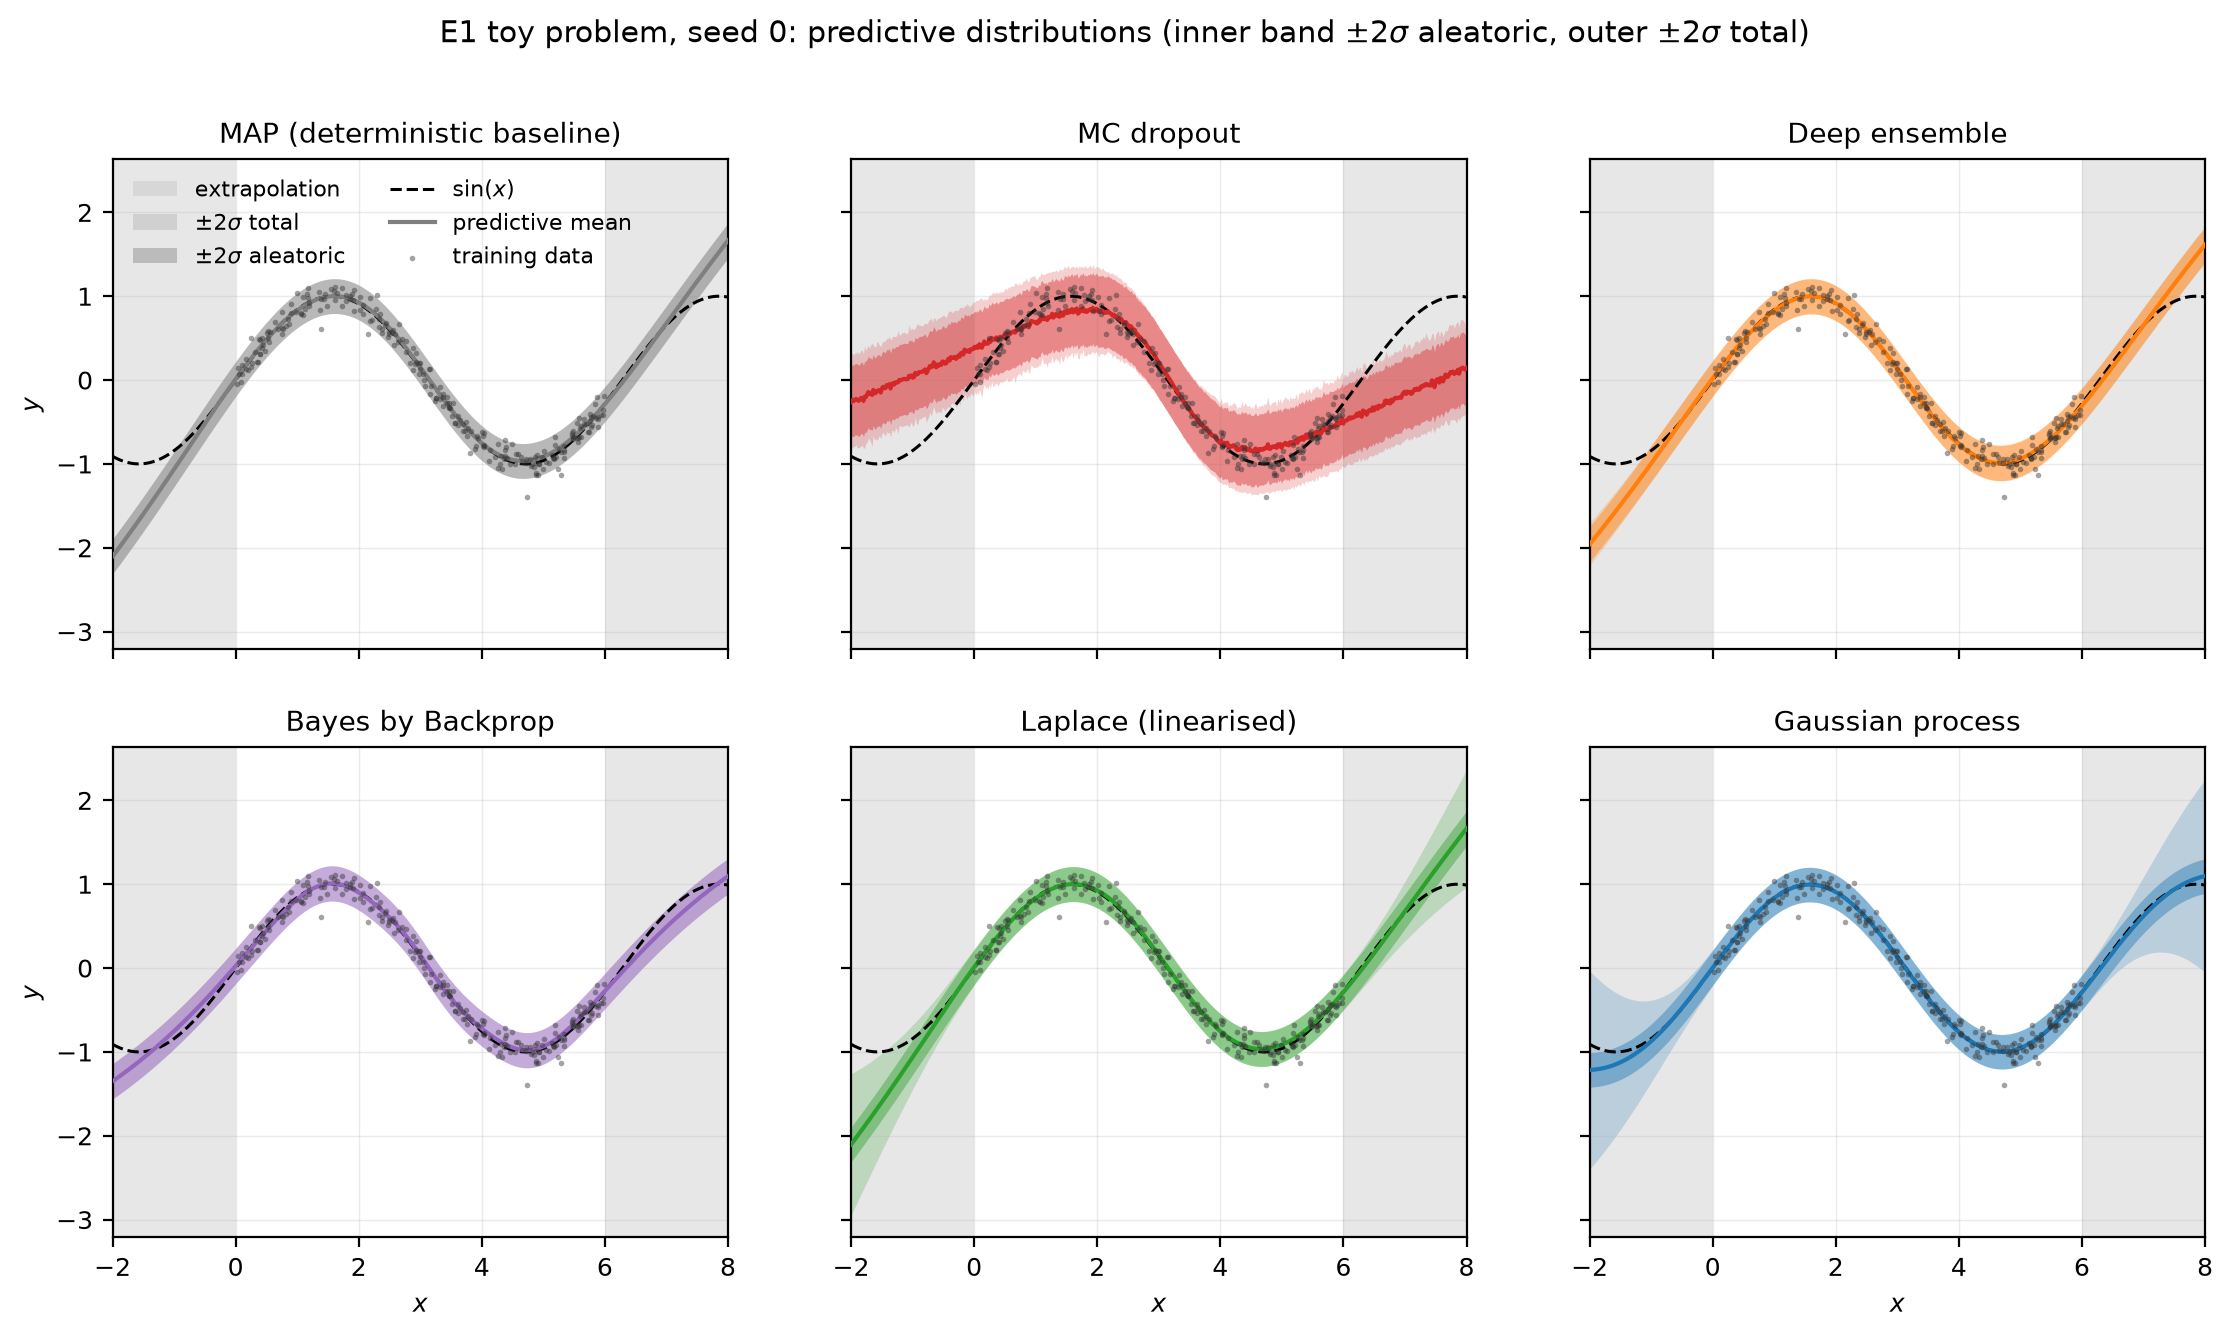

In [8]:
display(Image(filename=str(T.FIGURE_DIR / "e1_toy_all.png")))

**Panel zbiorczy (ziarno 0), wspólne osie.** Wspólne granice osi są tu istotne: pasmo
przycięte wyglądałoby na wąskie i odwróciłoby porównanie, dla którego ten rysunek
powstał. Czytać od lewej: `map` z pasmem stałej szerokości na całej dziedzinie, `mcd`
z pasmem szerokim wszędzie, `ensemble` i `bbb` z lekkim rozejściem na brzegach,
`laplace` i `gp` z wyraźnym rozdmuchaniem poza `[0, 6]`.

MAP — MAP — punkt odniesienia. Pasmo zewnętrzne pokrywa się z wewnętrznym: metoda nie ma członu epistemicznego, więc poza danymi jest równie pewna siebie jak w środku. To jest zachowanie, którego pozostałe pięć metod ma unikać.


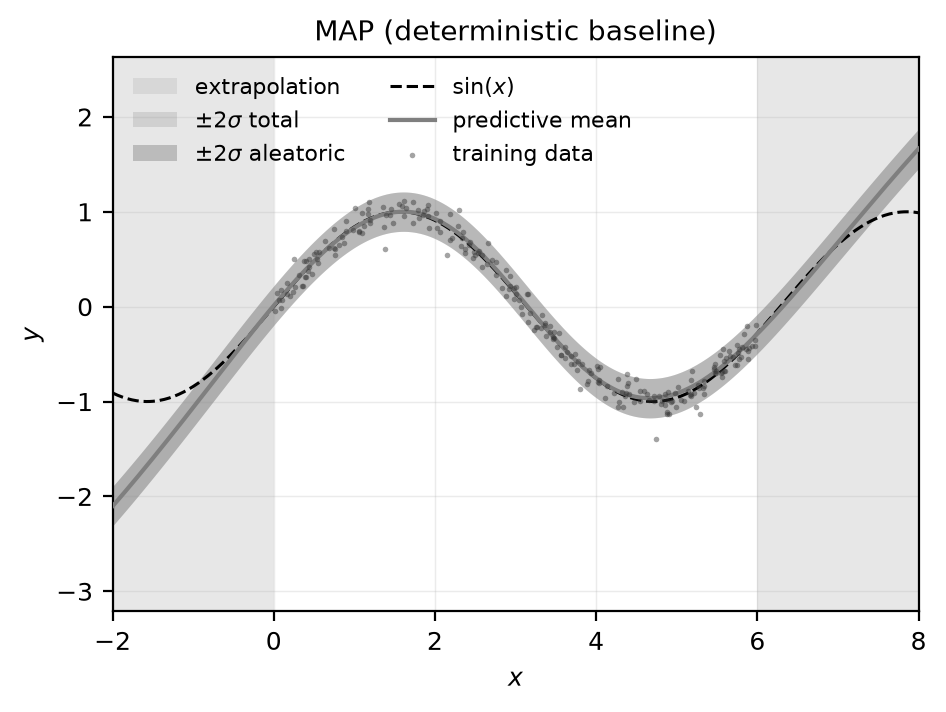

MCD — MC dropout — pasmo szerokie na całej dziedzinie, także tam, gdzie dane są gęste. Szerokość bierze się z szumu dropoutu wchłoniętego w globalny człon szumu (N-001), a nie z wiedzy o brakujących danych.


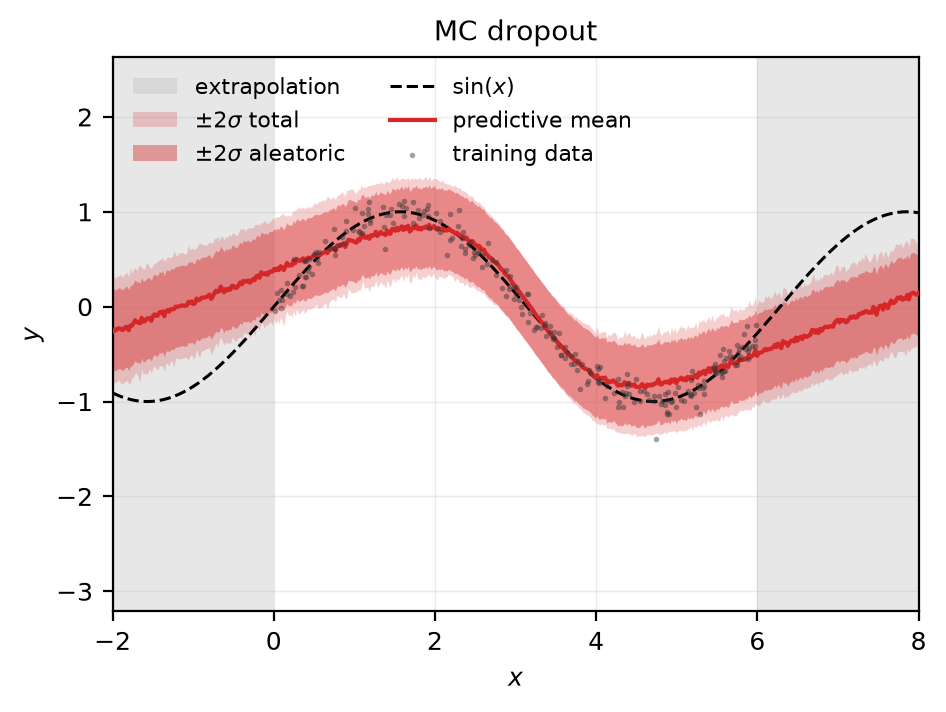

ENSEMBLE — Deep ensemble — pięć sieci startujących z różnych inicjalizacji. Rozjeżdżają się poza zakresem treningowym, ale znacznie słabiej niż gp i laplace.


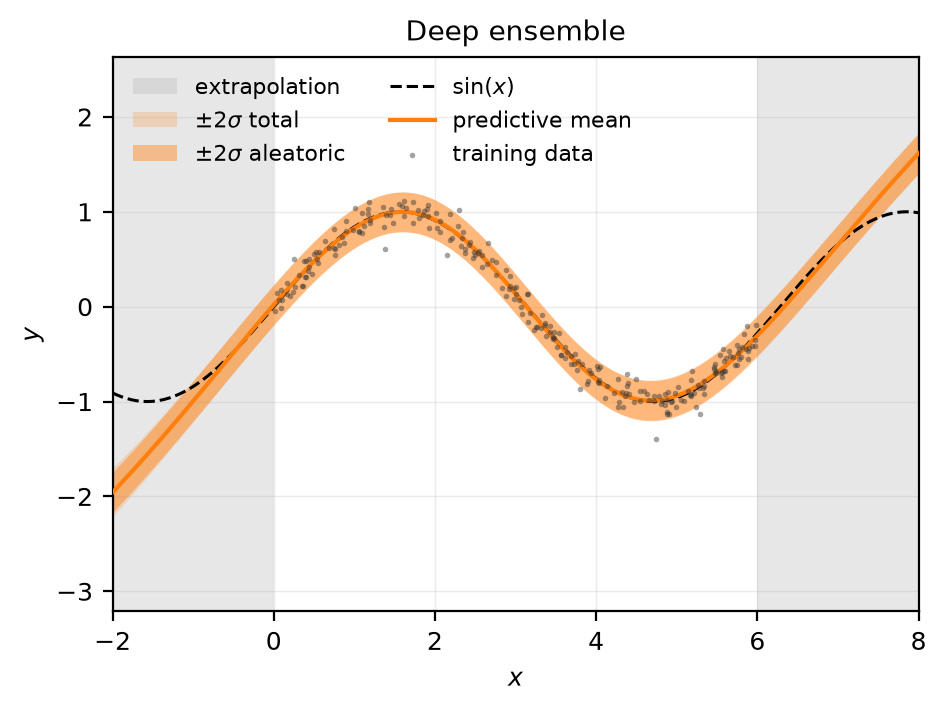

BBB — Bayes by Backprop — wariacyjna aproksymacja średniopolowa. Pasmo prawie nie reaguje na wyjście poza dane; to jest dokładnie ograniczenie, o którym mówi literatura dla rodziny średniopolowej przy jednej warstwie ukrytej.


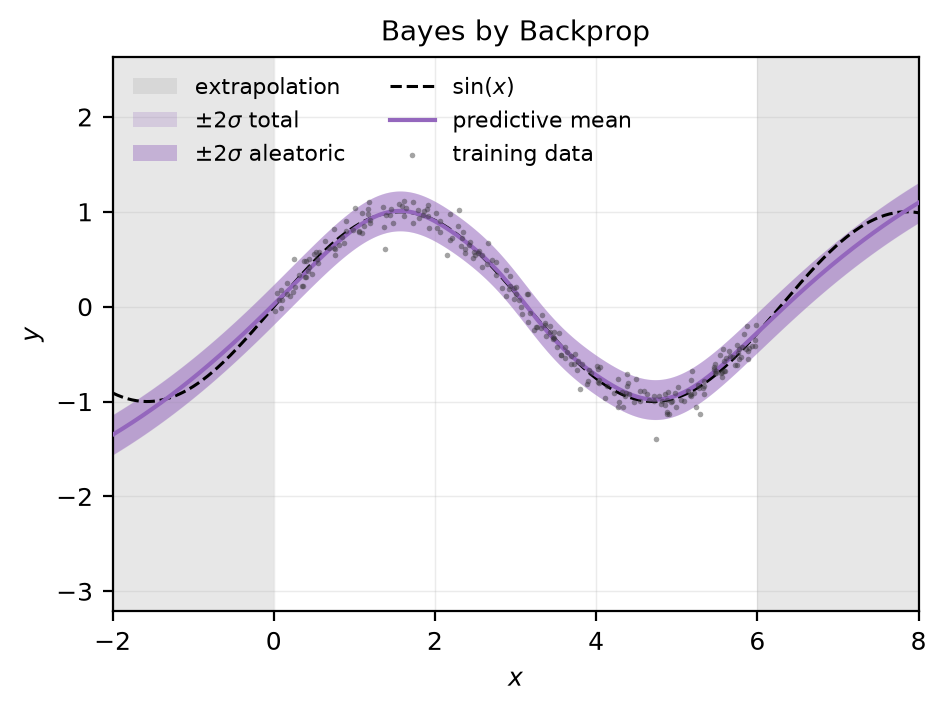

LAPLACE — Aproksymacja Laplace'a — pasmo rośnie wyraźnie poza [0, 6], bo krzywizna GGN jest tam mała i człon epistemiczny się otwiera. Średnia jest identyczna jak w map (to ta sama sieć MAP) — różni je wyłącznie niepewność.


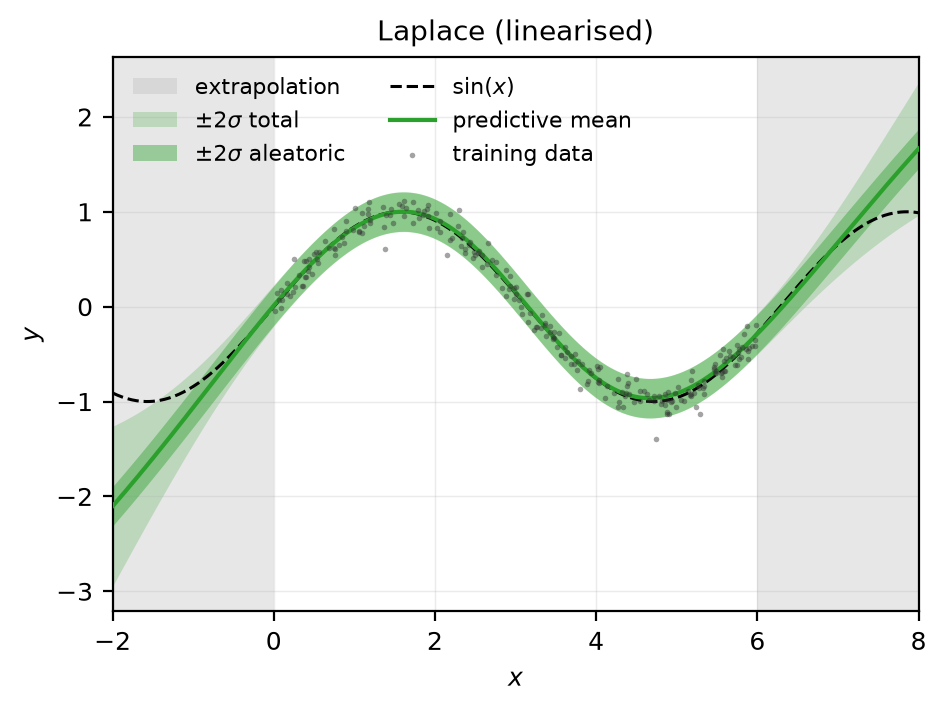

GP — Proces gaussowski — jedyna metoda z dokładną, a nie przybliżoną, rozkładem a posteriori. Pasmo wraca do a priori z dala od danych, co jest wzorcowym zachowaniem i punktem odniesienia dla pozostałych pięciu.


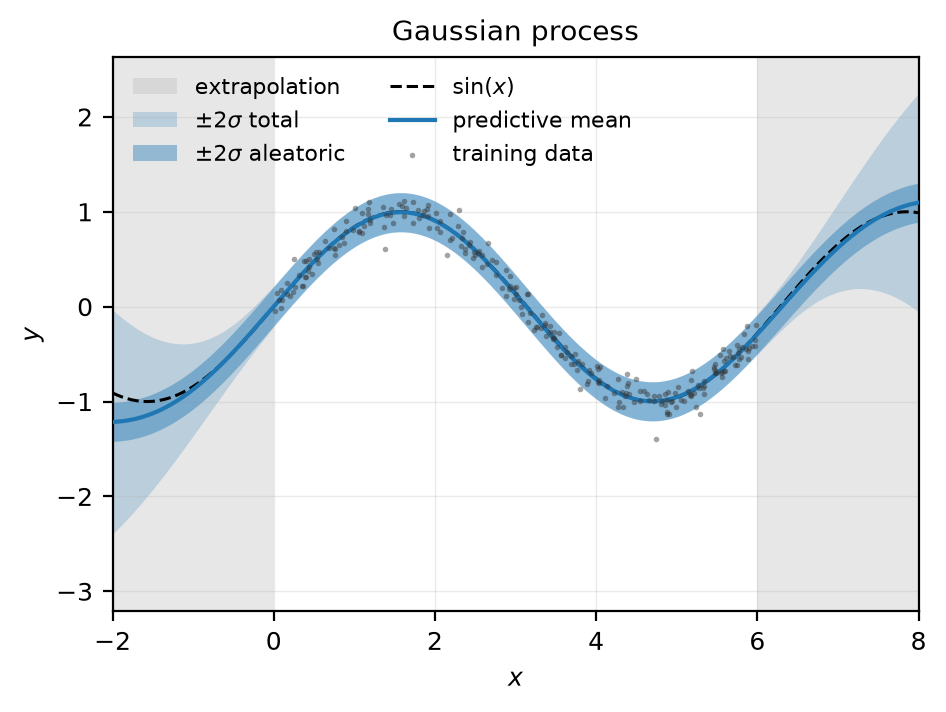

In [9]:
opisy = {
    "map":      "MAP — punkt odniesienia. Pasmo zewnętrzne pokrywa się z wewnętrznym: "
                "metoda nie ma członu epistemicznego, więc poza danymi jest równie pewna "
                "siebie jak w środku. To jest zachowanie, którego pozostałe pięć metod ma unikać.",
    "mcd":      "MC dropout — pasmo szerokie na całej dziedzinie, także tam, gdzie dane są gęste. "
                "Szerokość bierze się z szumu dropoutu wchłoniętego w globalny człon szumu (N-001), "
                "a nie z wiedzy o brakujących danych.",
    "ensemble": "Deep ensemble — pięć sieci startujących z różnych inicjalizacji. Rozjeżdżają się "
                "poza zakresem treningowym, ale znacznie słabiej niż gp i laplace.",
    "bbb":      "Bayes by Backprop — wariacyjna aproksymacja średniopolowa. Pasmo prawie nie reaguje "
                "na wyjście poza dane; to jest dokładnie ograniczenie, o którym mówi literatura "
                "dla rodziny średniopolowej przy jednej warstwie ukrytej.",
    "laplace":  "Aproksymacja Laplace'a — pasmo rośnie wyraźnie poza [0, 6], bo krzywizna GGN jest "
                "tam mała i człon epistemiczny się otwiera. Średnia jest identyczna jak w map "
                "(to ta sama sieć MAP) — różni je wyłącznie niepewność.",
    "gp":       "Proces gaussowski — jedyna metoda z dokładną, a nie przybliżoną, rozkładem a posteriori. "
                "Pasmo wraca do a priori z dala od danych, co jest wzorcowym zachowaniem i punktem "
                "odniesienia dla pozostałych pięciu.",
}
for name in ["map", "mcd", "ensemble", "bbb", "laplace", "gp"]:
    path = T.FIGURE_DIR / "e1_toy_{}.png".format(name)
    print("=" * 100)
    print(name.upper(), "—", opisy[name])
    display(Image(filename=str(path)))

## I.5 Eksport do LaTeX — Część I

Gotowe tabele `booktabs` do wklejenia do pracy. Wymagają `\usepackage{booktabs}`.
Notatnik **nie zapisuje** niczego do plików `.tex` — `CLAUDE.md` tego zabrania; tu tylko
drukuje tekst do skopiowania.

In [10]:
podpisy = {
    "in_range": "Problem syntetyczny, region w zakresie treningowym $[0, 6]$. "
                "Średnia $\\pm$ odchylenie standardowe po {n} ziarnach, oryginalne jednostki $y$. "
                "Błąd standardowy: $\\mathrm{{SE}} = \\mathrm{{std}}/\\sqrt{{{n}}}$.",
    "extrapolation": "Problem syntetyczny, region ekstrapolacji $[-2, 0] \\cup [6, 8]$. "
                "Średnia $\\pm$ odchylenie standardowe po {n} ziarnach, oryginalne jednostki $y$.",
    "overall": "Problem syntetyczny, cała siatka testowa $[-2, 8]$. "
                "Średnia $\\pm$ odchylenie standardowe po {n} ziarnach, oryginalne jednostki $y$.",
}
for region in T.E1_REGION_ORDER:
    print(T.to_latex(e1_tables[region],
                     caption=podpisy[region].format(n=n_e1),
                     label="tab:e1-{}".format(region.replace("_", "-"))))
    print()

\begin{table}[htbp]
  \centering
  \caption{Problem syntetyczny, region w zakresie treningowym $[0, 6]$. Średnia $\pm$ odchylenie standardowe po 20 ziarnach, oryginalne jednostki $y$. Błąd standardowy: $\mathrm{SE} = \mathrm{std}/\sqrt{20}$.}
  \label{tab:e1-in-range}
  \begin{tabular}{lrrrrrrr}
    \toprule
    metoda & RMSE & LL & PICP@95 & MPIW@95 & sigma\_fitted & cal\_err & cal\_bias \\
    \midrule
    map & 0.102 $\pm$ 0.006 & 0.857 $\pm$ 0.059 & 0.943 $\pm$ 0.019 & 0.396 $\pm$ 0.016 & 0.1011 $\pm$ 0.0042 & 0.0238 $\pm$ 0.0100 & -0.0012 $\pm$ 0.0240 \\
    mcd & 0.154 $\pm$ 0.008 & 0.310 $\pm$ 0.045 & 0.999 $\pm$ 0.003 & 0.949 $\pm$ 0.052 & 0.2018 $\pm$ 0.0120 & 0.1352 $\pm$ 0.0169 & 0.1352 $\pm$ 0.0169 \\
    ensemble & 0.100 $\pm$ 0.005 & 0.875 $\pm$ 0.045 & 0.950 $\pm$ 0.016 & 0.400 $\pm$ 0.017 & 0.1007 $\pm$ 0.0043 & 0.0240 $\pm$ 0.0113 & 0.0053 $\pm$ 0.0242 \\
    bbb & 0.102 $\pm$ 0.004 & 0.857 $\pm$ 0.041 & 0.950 $\pm$ 0.015 & 0.406 $\pm$ 0.017 & 0.1027 $\pm$ 0.0044 & 0.0

---
# Część II — dane rzeczywiste (E2)

**Zadanie.** Trzy zbiory UCI (`yacht`, `energy`, `concrete`) na **oryginalnych podziałach
Hernándeza-Lobato i Adamsa (2015)** — tych samych 20 podziałach 90/10, na których raportują
Gal i Ghahramani (2016) oraz Lakshminarayanan i in. (2017). Podziały są wczytywane
z plików indeksów, nie losowane u nas.

**Co się zmienia względem Części I — i trzeba to mieć z tyłu głowy:**

1. **Nie ma regionu ekstrapolacji.** Zbiór testowy pochodzi z tego samego rozkładu co
   treningowy, więc nie ma czego rozdzielać: jeden wiersz na (metoda, zbiór).
2. **Nie ma rysunków.** Wejście ma 6–8 wymiarów, więc nie da się narysować pasma
   w funkcji `x`. To nie jest brak — E2 z założenia raportuje same liczby.
3. **Nie ma znanego poziomu szumu.** Nikt nie wie, ile naprawdę wynosi szum obserwacyjny
   w tych zbiorach — jego estymacja jest częścią zadania. Dlatego `sigma_fitted` czyta się
   tu **wyłącznie względnie** (czy `mcd` zawyża w stosunku do pozostałych pięciu na tych
   samych danych), a nie względem prawdy.
4. **Ziarno steruje czym innym.** W E1 ziarno losowało dane *i* model. Tu podział jest
   ustalony przez pliki indeksów, więc ziarno (`seed = numer splitu`) steruje tylko
   inicjalizacją sieci i kolejnością batchy. Rozrzut `±` miesza więc zmienność
   między podziałami ze zmiennością inicjalizacji — tak samo jak w protokole źródłowym,
   ale trzeba to napisać wprost.

**Przetwarzanie wstępne: standaryzacja i nic więcej.** Kolumny i cel są standaryzowane na
statystykach **treningowych** danego podziału, a predykcje odstandaryzowane przed liczeniem
metryk. Żadnych transformacji logarytmicznych, usuwania outlierów, kodowania one-hot ani
selekcji cech — każde z nich zniweczyłoby porównanie z opublikowanymi liczbami, które jest
jedyną zewnętrzną walidacją tego etapu.

In [11]:
display(T.style(
    T.e2_configuration(e2),
    "E2 — kształt zbiorów i reżim pojemnościowy (P = liczba parametrów jednej sieci)"))

,N_train,N_test,d,P,N_train/P,splity
zbiór,,,,,,
yacht,277,31,6,402,0.690000,20
energy,691,77,8,502,1.380000,20
concrete,927,103,8,502,1.850000,20


**Kolumna `N_train/P` jest ostrzeżeniem, nie ciekawostką.** Sieć ma `50·d + 102`
parametrów, więc na `yacht` jest ich **więcej niż punktów treningowych** (402 vs 277,
iloraz 0.69). Macierz krzywizny GGN ma rangę co najwyżej `N_train`, więc formalnie
124 kierunki w przestrzeni parametrów są tam określone przez a priori, a nie przez dane.

**Zostało to sprawdzone i okazało się nieszkodliwe (N-020):** te 124 kierunki wnoszą
**0.0000** wariancji epistemicznej w punktach testowych, bo jakobiany punktów testowych
nie mają wzdłuż nich składowej. Deficyt rangi jest realny, ale **nie przenosi się na
raportowane pasmo** dopóki punkty testowe pochodzą z tego samego rozkładu. W pracy
**nie wolno** napisać, że na `yacht` niepewność Laplace'a jest w dużej mierze
podyktowana a priori — to zostało zmierzone i jest nieprawdą.

Cały zakres `N_train/P` to 0.69–1.85, czyli oba etapy siedzą w reżimie małych danych.
E2 nie mówi nic o zachowaniu przy dużym `N`.

## II.1 Tabele metryk — komplet, po jednej na zbiór

Wszystkie sześć metod i wszystkie siedem kolumn. Rozrzut = odchylenie standardowe
po 20 podziałach. **Bez agregatu po zbiorach** (DEC-016): cele są w różnych jednostkach
(wytrzymałość betonu w MPa, obciążenie cieplne, opór szczątkowy kadłuba), więc średnia
RMSE po trzech zbiorach nie jest żadną wielkością.

In [12]:
e2_tables = T.stage_tables(e2, "dataset", T.E2_DATASET_ORDER)
n_e2 = T.repetitions(e2, "dataset", "yacht")

display(T.style(
    e2_tables["yacht"],
    "E2 — yacht (N_train 277, N_test 31, d 6) · średnia ± odchylenie standardowe "
    "po {} podziałach · oryginalne jednostki celu".format(n_e2)))

,RMSE,LL,PICP@95,MPIW@95,sigma_fitted,cal_err,cal_bias
metoda,,,,,,,
map,0.562 ± 0.173,-1.017 ± 0.591,0.903 ± 0.056,1.684 ± 0.210,0.4295 ± 0.0535,0.0835 ± 0.0256,0.0264 ± 0.0622
mcd,1.668 ± 0.483,-2.328 ± 0.086,0.987 ± 0.019,13.714 ± 0.329,2.7320 ± 0.0879,0.2502 ± 0.0426,0.2455 ± 0.0495
ensemble,0.492 ± 0.169,-0.566 ± 0.144,0.965 ± 0.033,2.167 ± 0.181,0.4142 ± 0.0179,0.1675 ± 0.0452,0.1631 ± 0.0478
bbb,0.625 ± 0.302,-1.300 ± 1.212,0.884 ± 0.077,1.729 ± 0.176,0.4367 ± 0.0447,0.1043 ± 0.0740,-0.0145 ± 0.1222
laplace,0.562 ± 0.173,-0.679 ± 0.182,0.953 ± 0.045,2.023 ± 0.208,0.4295 ± 0.0535,0.0964 ± 0.0415,0.0739 ± 0.0571
gp,0.436 ± 0.149,-0.148 ± 0.196,0.919 ± 0.055,1.055 ± 0.220,0.1510 ± 0.0131,0.0667 ± 0.0246,-0.0069 ± 0.0610


**yacht.** `gp` wygrywa wyraźnie i w RMSE, i w LL (−0.148 wobec −0.566 u następnego).
`mcd` jest najgorszy z dużym marginesem, z pasmem 6× szerszym niż reszta — to ten sam
mechanizm co w E1, tylko silniejszy (patrz II.4).

**Ograniczenie do zaraportowania, nie do naprawienia (N-016):** cel `yacht` (opór
szczątkowy) jest silnie skośny (skośność +1.75), nieujemny, a **połowa obserwacji leży
w dolnych 5% zakresu**. Wszystkie metody używają homoskedastycznego rozkładu Gaussa, więc
jedna globalna sigma dość duża, by objąć ogon, siłą rzeczy kładzie istotną masę
prawdopodobieństwa **poniżej zera** dla wielu obserwacji bliskich zeru. To uderza
dokładnie w `LL`, `PICP`, `MPIW` i parę kalibracyjną — `RMSE` tego nie widzi.

In [13]:
display(T.style(
    e2_tables["energy"],
    "E2 — energy (N_train 691, N_test 77, d 8) · średnia ± odchylenie standardowe "
    "po {} podziałach · oryginalne jednostki celu".format(n_e2)))

,RMSE,LL,PICP@95,MPIW@95,sigma_fitted,cal_err,cal_bias
metoda,,,,,,,
map,0.474 ± 0.076,-0.804 ± 0.299,0.881 ± 0.042,1.387 ± 0.070,0.3538 ± 0.0178,0.0633 ± 0.0293,-0.0546 ± 0.0396
mcd,1.165 ± 0.113,-1.769 ± 0.036,0.998 ± 0.005,7.668 ± 0.173,1.5833 ± 0.0370,0.1696 ± 0.0296,0.1696 ± 0.0296
ensemble,0.401 ± 0.059,-0.517 ± 0.139,0.963 ± 0.015,1.702 ± 0.065,0.3505 ± 0.0074,0.0775 ± 0.0261,0.0749 ± 0.0278
bbb,0.524 ± 0.056,-0.843 ± 0.188,0.902 ± 0.031,1.678 ± 0.124,0.4267 ± 0.0315,0.0512 ± 0.0285,-0.0278 ± 0.0474
laplace,0.474 ± 0.076,-0.700 ± 0.217,0.920 ± 0.033,1.579 ± 0.071,0.3538 ± 0.0178,0.0424 ± 0.0182,-0.0157 ± 0.0386
gp,0.466 ± 0.067,-0.665 ± 0.165,0.923 ± 0.027,1.712 ± 0.045,0.3848 ± 0.0085,0.0541 ± 0.0225,0.0377 ± 0.0342


**energy.** `ensemble` najlepszy w RMSE i LL, `laplace` najlepiej skalibrowany
(`cal_err` 0.0424), `gp` w środku stawki — czyli **inny porządek niż na `yacht`**.

> **Uwaga do wiersza `gp` — nie cytować bez tego zastrzeżenia (N-021).** Amplituda jądra
> (`constant_value`) wylądowała **dokładnie na górnej granicy `1e5` we wszystkich 20
> podziałach**, a 16 z 20 dopasowań zgłosiło ostrzeżenie o braku zbieżności. Wartość jest
> więc ustalona przez granicę, a nie przez dane. Szczegóły i pomiar skutków — sekcja II.3.

**Drugie ograniczenie (N-016):** `energy` ma jedną cechę binarną i trzy czterowartościowe
(orientacja budynku, rozkład przeszkleń), traktowane jak zmienne ciągłe i standaryzowane —
tak jak robi to źródłowe repozytorium. Kodowanie one-hot byłoby uzasadnione modelarsko,
ale zmieniłoby `d`, a z nim liczbę parametrów i porównywalność z literaturą.

In [14]:
display(T.style(
    e2_tables["concrete"],
    "E2 — concrete (N_train 927, N_test 103, d 8) · średnia ± odchylenie standardowe "
    "po {} podziałach · oryginalne jednostki celu".format(n_e2)))

,RMSE,LL,PICP@95,MPIW@95,sigma_fitted,cal_err,cal_bias
metoda,,,,,,,
map,4.958 ± 0.475,-3.615 ± 0.351,0.812 ± 0.033,10.640 ± 0.586,2.7143 ± 0.1495,0.0962 ± 0.0333,-0.0928 ± 0.0375
mcd,5.611 ± 0.385,-3.159 ± 0.053,0.965 ± 0.015,24.654 ± 0.387,5.6167 ± 0.1123,0.0679 ± 0.0245,0.0658 ± 0.0254
ensemble,4.352 ± 0.657,-2.861 ± 0.211,0.920 ± 0.031,13.902 ± 0.544,2.7161 ± 0.0883,0.0479 ± 0.0193,0.0287 ± 0.0306
bbb,5.279 ± 0.703,-3.667 ± 0.452,0.809 ± 0.041,11.471 ± 0.827,2.9193 ± 0.2106,0.1147 ± 0.0320,-0.1140 ± 0.0326
laplace,4.958 ± 0.475,-3.082 ± 0.218,0.871 ± 0.036,13.042 ± 0.650,2.7143 ± 0.1495,0.0536 ± 0.0213,-0.0384 ± 0.0347
gp,5.406 ± 0.466,-3.065 ± 0.088,0.937 ± 0.024,19.875 ± 0.399,4.3809 ± 0.0900,0.0391 ± 0.0187,0.0230 ± 0.0273


**concrete — i tu pada najciekawszy wynik negatywny całego etapu.** `gp` ma
**najgorsze RMSE ze wszystkich sześciu metod** (5.406 wobec 4.352 u `ensemble`),
a jednocześnie **najlepszy `cal_err`**. Czyli: dokładny proces gaussowski nie jest
automatycznie najlepszą metodą na prawdziwych danych — jest najlepiej skalibrowany,
ale najgorzej dopasowany. Obraz z E1, gdzie `gp` był wzorcem pod każdym względem,
**nie przenosi się na dane rzeczywiste**.

**Porównaj wiersze `map` i `laplace`:** identyczne RMSE i identyczne `sigma_fitted` (na
wszystkich trzech zbiorach, sprawdzone per podział) — bo średnia predykcyjna Laplace'a
**jest** siecią MAP. Różnią się wyłącznie w LL, PICP, MPIW i kalibracji. Na `concrete` to
zamienia LL −3.615 na −3.082 przy zerowej zmianie RMSE. **To jest najczystsza w całej
pracy demonstracja tego, co kupuje się, dokładając aparat niepewności do gotowego modelu.**

**Ograniczenie (N-018):** `concrete` zawiera 25 zduplikowanych wierszy, więc 70 z 2060
wierszy testowych (3.4%) powtarza co do wartości wiersz treningowy. Podziały są rozłączne
indeksowo — to własność samych danych, na których uczył się Gal. Wszystkie metody
korzystają z tego jednakowo, więc porównanie między metodami jest nienaruszone; lekko
optymistyczny jest bezwzględny poziom liczb na tym zbiorze.

## II.2 Kalibracja jednym rzutem oka

Nominalny poziom to **0.95**. Poniżej sama kolumna PICP@95 zestawiona dla trzech zbiorów.

In [15]:
picp = (T.summarise(e2, ["method", "dataset"], ["picp95"])
        .pivot(index="method", columns="dataset", values="picp95_mean")
        .reindex(list(T.METHOD_ORDER))[list(T.E2_DATASET_ORDER)]
        .round(3))
picp.index.name = "metoda"
display(T.style(picp, "E2 — PICP@95 (nominał 0.95); < 0.95 = nadpewność, > 0.95 = niedopewność"))

dataset,yacht,energy,concrete
metoda,,,
map,0.903000,0.881000,0.812000
mcd,0.987000,0.998000,0.965000
ensemble,0.965000,0.963000,0.920000
bbb,0.884000,0.902000,0.809000
laplace,0.953000,0.920000,0.871000
gp,0.919000,0.923000,0.937000


**Nic nie jest dobrze skalibrowane inaczej niż przypadkiem.** Sześć metod rozciąga się od
0.809 do 0.998. `map` i `bbb` mają na `concrete` pokrycie ~0.81 przy nominale 0.95 (czyli
są zdecydowanie zbyt pewne siebie), a `mcd` przekracza nominał wszędzie, dochodząc do
0.998 na `energy` — przedział praktycznie zawsze trafia, bo jest absurdalnie szeroki.

To jest wniosek, który warto postawić w pracy wprost: **na danych rzeczywistych żadna
z tych metod nie daje przedziału o zadeklarowanym pokryciu**, a kierunek błędu różni się
między metodami.

## II.3 Diagnostyka jądra GP — dlaczego wiersz `gp` dla `energy` jest zastrzeżony

Skrypt zapisuje każdy dopasowany hiperparametr jądra wraz z jego granicami do osobnego
pliku `results/e2_uci_gp_kernels.csv`. Powód: **hiperparametr leżący na granicy jest
ustalony przez tę granicę, a nie przez dane** — a wtedy przebiegu nie wolno raportować bez
zastrzeżenia. `min. margines (log)` to odległość do najbliższej granicy w skali
logarytmicznej (w niej działa optymalizator); `0.0` oznacza dokładne przyleganie.

In [16]:
display(T.style(
    T.gp_kernel_summary(),
    "E2 — dopasowane hiperparametry jądra GP i ich odległość od granic (20 podziałów na zbiór)"))

**`yacht` i `concrete` są czyste** — żaden hiperparametr nie zbliża się do granicy bliżej
niż 8.7 jednostki logarytmicznej, zero ostrzeżeń o zbieżności. Problem dotyczy wyłącznie
`energy`, i tam jest zupełny: 20 podziałów na 20.

**Czy to psuje liczby? Zmierzone osobno.** Przeliczenie `energy` z granicą amplitudy
poszerzoną do `1e12` (diagnostyka, nic z niej nie trafiło do `results/`) daje:

| ustawienie | RMSE | LL | PICP@95 | MPIW@95 | mediana `constant_value` |
|---|---|---|---|---|---|
| granica `1e5` — **tak jak raportujemy** | 0.4662 ± 0.0670 | −0.6655 ± 0.1654 | 0.9234 | 1.7118 | 1.00e+05 |
| granica `1e12` — tylko diagnostycznie | 0.4751 ± 0.0614 | −0.6869 ± 0.1577 | 0.9266 | 1.7333 | 2.11e+06 |

Granica **naprawdę wiąże** (zwolniona, amplituda ucieka jeszcze 21× wyżej, a log-wiarygodność
brzegowa rośnie średnio o 5.5), ale **predykcje prawie się nie ruszają** — i ruszają się
lekko **na gorsze**. To podpis klasycznej nieidentyfikowalności: amplituda i skala długości
uciekają razem, dobrze określony jest tylko ich stosunek. Poszerzenie granicy nie usuwa
problemu, tylko przesuwa go dalej.

**Decyzja należy do autora** (N-021): raportować wiersz z zastrzeżeniem, poszerzyć granicę
w `src/methods/gp.py` i przeliczyć oba etapy (bo jądro jest konfiguracją wspólną — E1
trzeba by puścić od nowa), albo zostawić tę komórkę pustą. Czego **nie wolno** zrobić, to
zaraportować ten wiersz bez wzmianki.

## II.4 `sigma_fitted` — porównanie względne (N-001 na danych rzeczywistych)

Na UCI nie ma prawdziwego poziomu szumu, więc jedyne uczciwe pytanie brzmi: czy `mcd`
zawyża swój człon szumu **w stosunku do pozostałych pięciu metod na tych samych danych**.

In [17]:
display(T.style(
    T.mcd_noise_inflation(e2),
    "E2 — dopasowany szum mcd wobec średniej z pozostałych pięciu metod"))

,mcd sigma_fitted,pozostałe pięć (średnia),iloraz (sd),iloraz (wariancja)
zbiór,,,,
yacht,2.732000,0.372200,7.340000,53.900000
energy,1.583300,0.373900,4.230000,17.900000
concrete,5.616700,3.089000,1.820000,3.300000


**N-001 potwierdza się na danych rzeczywistych, a jego siła zależy od zbioru** — i to jest
nowa informacja względem E1. Zawyżenie jest tym większe, im mniej prawdziwego szumu ma
zbiór: `yacht` to niemal deterministyczny eksperyment projektowany (GP dopasowuje mu
`noise_level` rzędu `1e-4`), więc szum dropoutu nie ma gdzie się podziać poza globalnym
`log_sigma2` i wychodzi ~54× w wariancji. `concrete` ma realny szum obserwacyjny
i zawyżenie niemal znika (3.3×).

Dla porównania: w E1 było to 4.07× w wariancji wobec **znanej** prawdy 0.1.

## II.5 Porównanie z literaturą — kontrola poprawności, nie wynik

Nasze `mcd` obok liczb opublikowanych w repozytorium `yaringal/DropoutUncertaintyExps`
(1 warstwa ukryta, 40×100 epok, te same 20 podziałów).

In [18]:
display(T.style(
    T.e2_reference_comparison(e2),
    "E2 — nasze mcd vs. opublikowane wyniki per podział (obie kolumny jako średnia ± odchylenie standardowe)"))

,RMSE (nasze),RMSE (literatura),LL (nasze),LL (literatura)
zbiór,,,,
yacht,1.668 ± 0.483,0.666 ± 0.223,-2.328 ± 0.086,-1.250 ± 0.070
energy,1.165 ± 0.113,0.539 ± 0.062,-1.769 ± 0.036,-1.212 ± 0.024
concrete,5.611 ± 0.385,4.826 ± 0.737,-3.159 ± 0.053,-2.937 ± 0.114


**To jest kontrola pipeline'u, a nie wynik tej pracy — i tak trzeba to opisać.**

**Uwaga o konwencji:** opublikowane tabele podają **błędy standardowe**, nasze —
odchylenia standardowe. Kolumna „literatura" powyżej została **przeliczona**
(`std = SE · √n`), żeby obie strony były na tej samej konwencji. Bez tego przeliczenia
porównanie rozrzutów byłoby czystym artefaktem.

**Kryterium zaliczenia to ten sam rząd wielkości, nie równość** — i jest spełnione na
wszystkich trzech zbiorach. Jesteśmy gorsi wszędzie (2.5×, 2.2× i 1.16× w RMSE), a różnica
jest największa dokładnie tam, gdzie największe jest zawyżenie z II.4. Pozostają cztery
znane rozbieżności, żadna z nich nie jest tu zamykana:

1. `dropout_p` ustalone na 0.1 wobec ich strojonej siatki `(dropout_rate, tau)` — na tych
   zbiorach Gal używa 0.05 i 0.005;
2. kara a priori wyprowadzona z `gamma` wobec ich regularyzacji L2 wyprowadzonej z `tau`;
3. nasza pojedyncza gaussowska aproksymacja momentowa (DEC-009) wobec ich mieszanki
   log-sum-exp;
4. ich RMSE jest uśrednione po przebiegach stochastycznych.

Wniosek: **ta tabela waliduje pipeline, a nie naszą konfigurację `mcd`.**

## II.6 Eksport do LaTeX — Część II

In [19]:
for name in T.E2_DATASET_ORDER:
    print(T.to_latex(
        e2_tables[name],
        caption="Zbiór {}. Średnia $\\pm$ odchylenie standardowe po {} podziałach "
                "Hern\\'andeza-Lobato i Adamsa, oryginalne jednostki zmiennej celu. "
                "Błąd standardowy: $\\mathrm{{SE}} = \\mathrm{{std}}/\\sqrt{{{n}}}$."
                .format(name, n_e2, n=n_e2),
        label="tab:e2-{}".format(name)))
    print()

\begin{table}[htbp]
  \centering
  \caption{Zbiór yacht. Średnia $\pm$ odchylenie standardowe po 20 podziałach Hern\'andeza-Lobato i Adamsa, oryginalne jednostki zmiennej celu. Błąd standardowy: $\mathrm{SE} = \mathrm{std}/\sqrt{20}$.}
  \label{tab:e2-yacht}
  \begin{tabular}{lrrrrrrr}
    \toprule
    metoda & RMSE & LL & PICP@95 & MPIW@95 & sigma\_fitted & cal\_err & cal\_bias \\
    \midrule
    map & 0.562 $\pm$ 0.173 & -1.017 $\pm$ 0.591 & 0.903 $\pm$ 0.056 & 1.684 $\pm$ 0.210 & 0.4295 $\pm$ 0.0535 & 0.0835 $\pm$ 0.0256 & 0.0264 $\pm$ 0.0622 \\
    mcd & 1.668 $\pm$ 0.483 & -2.328 $\pm$ 0.086 & 0.987 $\pm$ 0.019 & 13.714 $\pm$ 0.329 & 2.7320 $\pm$ 0.0879 & 0.2502 $\pm$ 0.0426 & 0.2455 $\pm$ 0.0495 \\
    ensemble & 0.492 $\pm$ 0.169 & -0.566 $\pm$ 0.144 & 0.965 $\pm$ 0.033 & 2.167 $\pm$ 0.181 & 0.4142 $\pm$ 0.0179 & 0.1675 $\pm$ 0.0452 & 0.1631 $\pm$ 0.0478 \\
    bbb & 0.625 $\pm$ 0.302 & -1.300 $\pm$ 1.212 & 0.884 $\pm$ 0.077 & 1.729 $\pm$ 0.176 & 0.4367 $\pm$ 0.0447 & 0.1043 $\

---
# Czego te tabele nie mówią — lista zastrzeżeń

Zebrane w jednym miejscu, żeby nie trzeba było ich wyławiać z `docs/experiment_notes.md`.
Pełne wpisy są tam, pod podanymi identyfikatorami.

| # | Czego dotyczy | Status |
|---|---|---|
| **N-001 / N-015** | `mcd` zawyża szum obserwacyjny, ale przy `dropout_p = 0.1` — 2–20× więcej niż używa Gal na tych zbiorach. Nie wolno pisać o „własności metody" bez podania wartości parametru. | otwarte, do opisania w tekście |
| **N-016** | `yacht` ma silnie skośny, nieujemny cel — homoskedastyczny Gauss kładzie masę poniżej zera. `energy` ma cechy kategoryczne traktowane jak ciągłe. | ograniczenia do zaraportowania, nie do naprawy |
| **N-018** | `concrete`: 25 zduplikowanych wierszy, 3.4% wierszy testowych powtarza wiersz treningowy. | własność danych, opisana |
| **N-019** | Biblioteka `curvlinops` przepuszcza krzywiznę Laplace'a przez float32. Na `yacht` wskaźnik uwarunkowania urósł do 7.5e6 (E1: 1.26e5) — na granicy przyjętego progu. Zmierzony błąd: 0.017% szerokości pasma. | **decyzja autora** |
| **N-020** | Deficyt rangi na `yacht` jest realny, ale **nie** przenosi się na raportowane pasmo. Przewidywanie z N-013 zostało zmierzone i się nie potwierdziło. | zamknięte pomiarem |
| **N-021** | `energy`, `gp`: amplituda jądra na górnej granicy w 20/20 podziałów. Wpływ na metryki < 2% w średniej. | **decyzja autora** |
| **DEC-016** | Brak agregatu po zbiorach — porównania formułować per zbiór, prozą. | ustalone |